In [3]:
path = 'AD_all_patients.csv'

In [4]:
#import all libraries necessary for random forest regression
import random
import numpy as np

import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from IPython.display import Image

import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


ModuleNotFoundError: No module named 'pandas'

In [5]:
# Visualize tabular dataset before proceeding with feature separation & random forest classification
main=pd.read_csv(path)
print(main)

              Fp1       Fp2        F7        F3         Fz        F4  \
0       116.99375  41.09375  66.69375 -64.50625 -126.40625   8.39375   
1       115.93125  38.63125  64.73125 -64.66875 -125.26875   8.73125   
2       115.72500  38.32500  66.02500 -62.67500 -135.37500   9.02500   
3       120.15625  40.75625  71.05625 -59.54375 -148.34375  12.15625   
4       119.50000  39.50000  71.30000 -59.20000 -125.50000  14.80000   
...           ...       ...       ...       ...        ...       ...   
848635   16.32500  43.62500  68.62500   8.52500  -56.37500   0.82500   
848636   16.24375  42.34375  70.64375  10.64375  -50.75625   1.84375   
848637   13.93125  36.93125  72.73125  12.43125  -45.36875   3.13125   
848638   10.71875  32.71875  74.11875  13.01875  -43.88125   4.31875   
848639    8.00000  28.60000  72.40000   9.30000  -47.00000   0.80000   

              F8        T3        C3        Cz        C4        T4         T5  \
0       22.49375  42.19375  53.29375   4.49375   2.493

In [6]:
#separate into labels & features and run a random forest

x=main.drop(columns='status')
y=main.status

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [7]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
# test
y_pred = rf.predict(X_test)

Accuracy: 0.9991928261689291


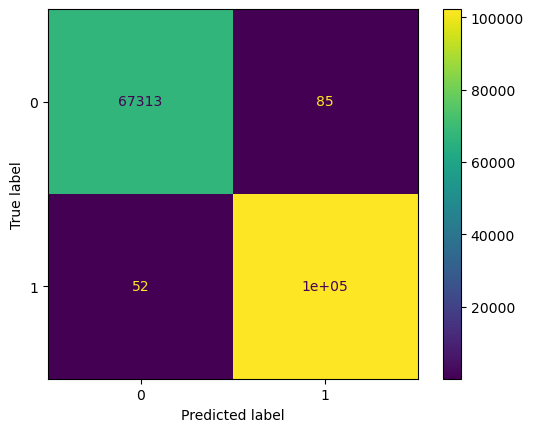

In [9]:
#accuracy
import matplotlib
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot();



<Axes: >

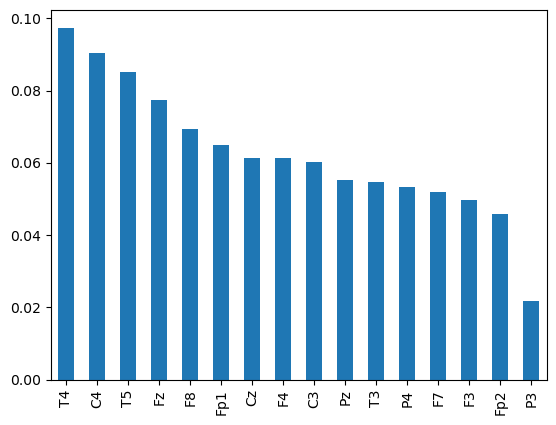

In [10]:
#feature analysis
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar()